In [368]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [369]:
df=pd.read_csv("Sales_with_NaNs_v1.3.csv")

In [370]:
df.head()

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,Control,High Value,240.548359,300.007568,74.684767,NaN,No
1,Treatment,High Value,246.862114,381.337555,100.000000,100.000000,Yes
2,Control,High Value,156.978084,179.330464,98.780735,100.000000,No
3,Control,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes
4,NaN,High Value,229.685623,NaN,83.974852,87.738591,Yes


In [371]:
df.shape

(10000, 7)

In [372]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Group                         8599 non-null   object 
 1   Customer_Segment              8034 non-null   object 
 2   Sales_Before                  8478 non-null   float64
 3   Sales_After                   9233 non-null   float64
 4   Customer_Satisfaction_Before  8330 non-null   float64
 5   Customer_Satisfaction_After   8360 non-null   float64
 6   Purchase_Made                 9195 non-null   object 
dtypes: float64(4), object(3)
memory usage: 547.0+ KB


In [373]:
df.tail()

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
9995,Treatment,NaN,259.695935,415.181694,88.438776,98.418593,NaN
9996,Control,High Value,186.488285,216.225457,92.261537,100.000000,NaN
9997,Treatment,Low Value,208.107142,322.893351,55.915870,NaN,No
9998,Treatment,Medium Value,NaN,431.974901,66.082462,81.274030,No
9999,Control,Low Value,NaN,124.402398,55.692277,65.288480,Yes


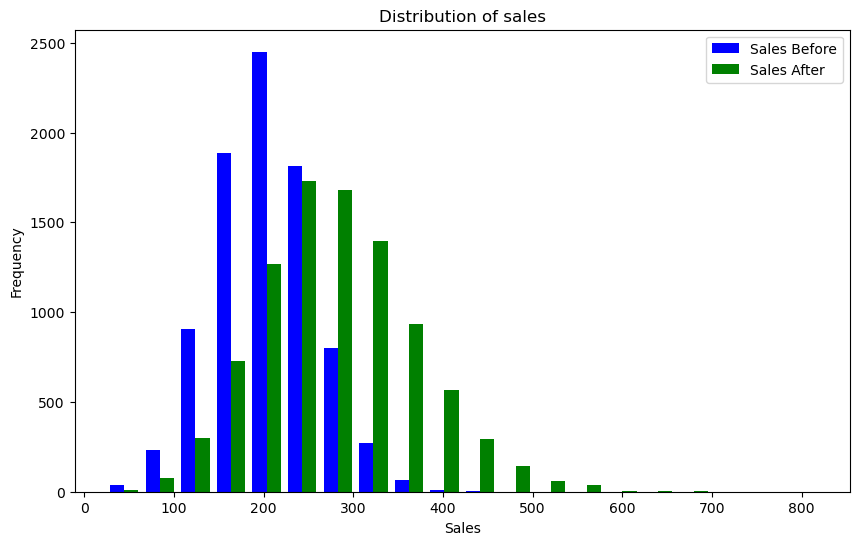

In [374]:
plt.figure(figsize=(10, 6))
plt.hist([df['Sales_Before'], df['Sales_After']], bins=20, color=['blue', 'green'], label=['Sales Before', 'Sales After'])
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of sales')
plt.legend()
plt.show()

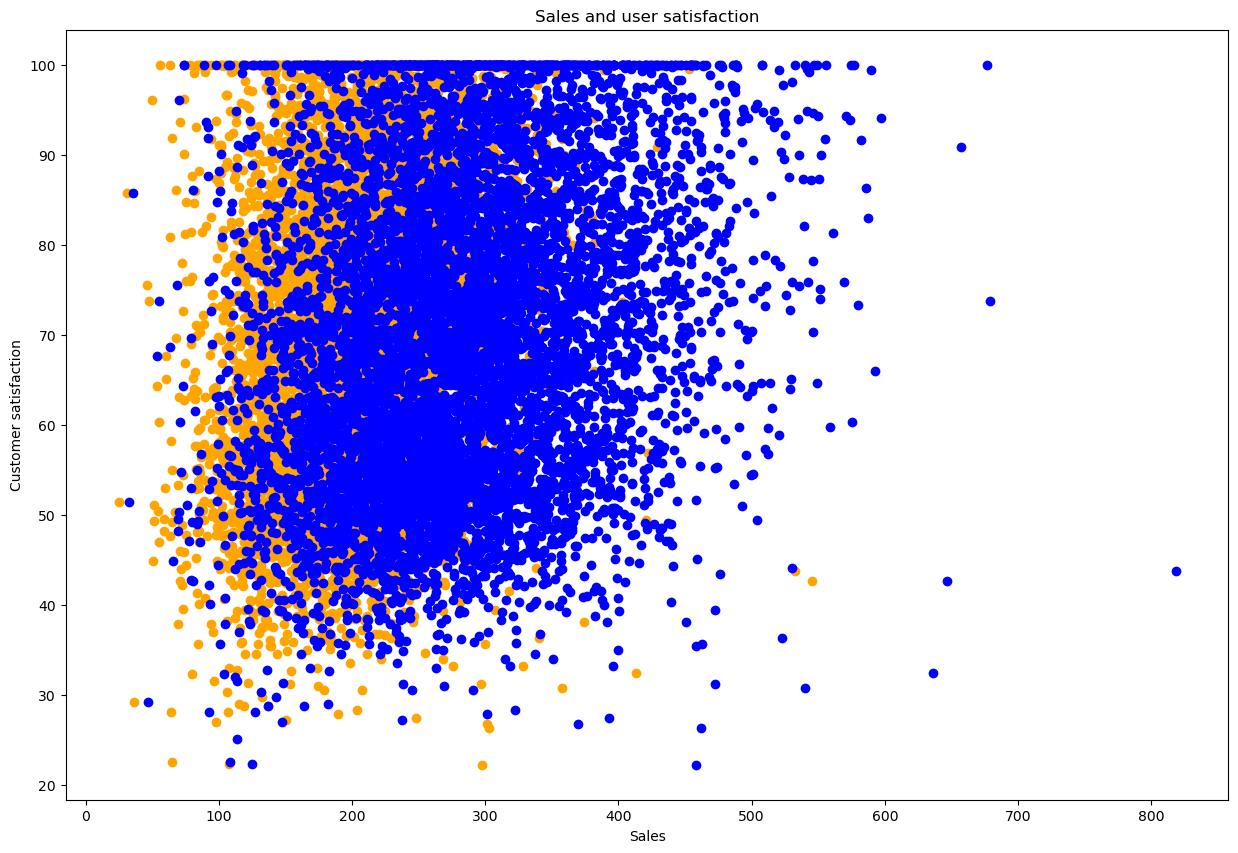

In [375]:
plt.figure(figsize=(15,10))
plt.scatter(df['Sales_Before'],df['Customer_Satisfaction_Before'],color='orange',label='Before')
plt.scatter(df['Sales_After'],df['Customer_Satisfaction_Before'],color='blue',label='After')
plt.xlabel('Sales')
plt.ylabel('Customer satisfaction')
plt.title('Sales and user satisfaction')
plt.show()

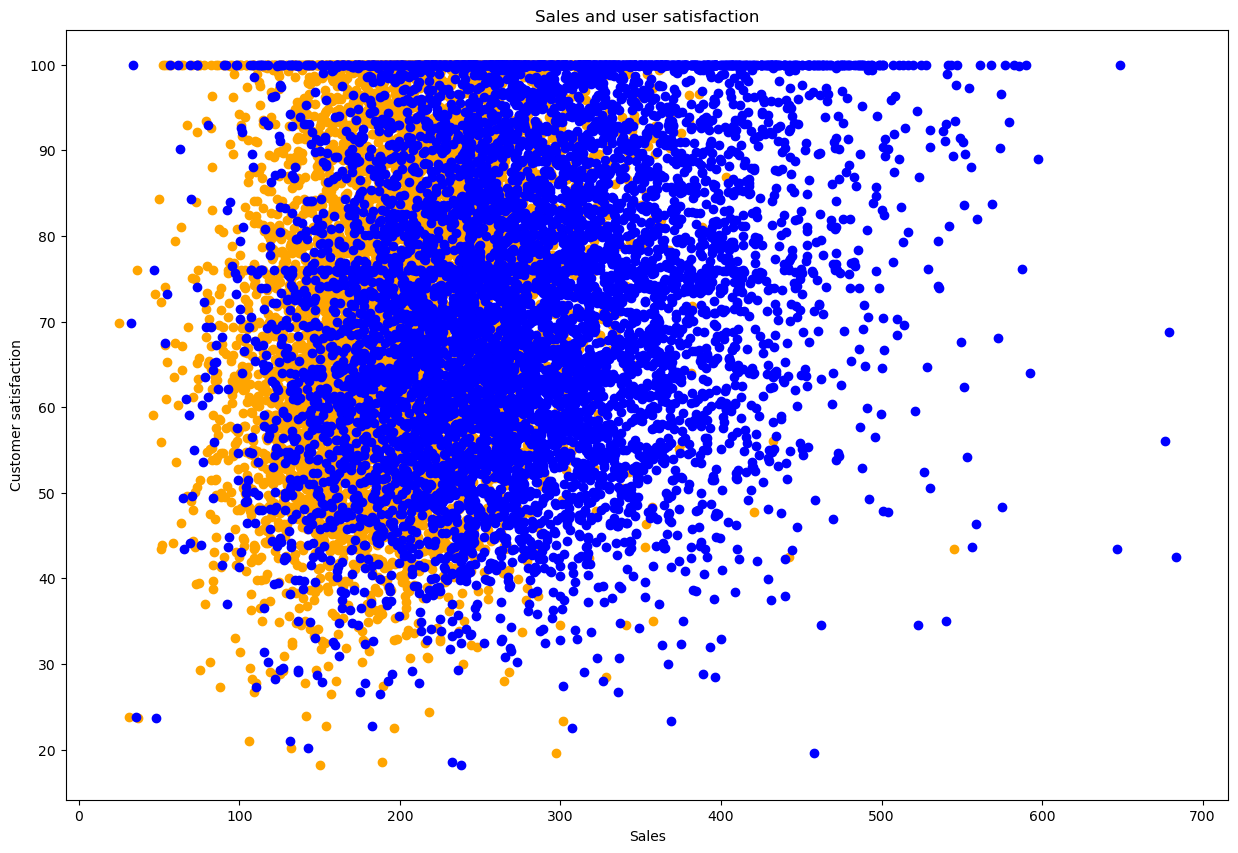

In [376]:
plt.figure(figsize=(15,10))
plt.scatter(df['Sales_Before'],df['Customer_Satisfaction_After'],color='orange',label='Before')
plt.scatter(df['Sales_After'],df['Customer_Satisfaction_After'],color='blue',label='After')
plt.xlabel('Sales')
plt.ylabel('Customer satisfaction')
plt.title('Sales and user satisfaction')
plt.show()

In [377]:
df

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,Control,High Value,240.548359,300.007568,74.684767,NaN,No
1,Treatment,High Value,246.862114,381.337555,100.000000,100.000000,Yes
2,Control,High Value,156.978084,179.330464,98.780735,100.000000,No
3,Control,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes
4,NaN,High Value,229.685623,NaN,83.974852,87.738591,Yes
...,...,...,...,...,...,...,...
9995,Treatment,NaN,259.695935,415.181694,88.438776,98.418593,NaN
9996,Control,High Value,186.488285,216.225457,92.261537,100.000000,NaN
9997,Treatment,Low Value,208.107142,322.893351,55.915870,NaN,No
9998,Treatment,Medium Value,NaN,431.974901,66.082462,81.274030,No


In [378]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [379]:
df['Customer_Satisfaction_After'].fillna(df['Customer_Satisfaction_After'].median(),inplace=True)
df['Customer_Satisfaction_Before'].fillna(df['Customer_Satisfaction_Before'].median(),inplace=True)
df['Sales_Before'].fillna(df['Sales_Before'].median(),inplace=True)
df['Sales_After'].fillna(df['Sales_After'].median(),inplace=True)

In [380]:
df

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,Control,High Value,240.548359,300.007568,74.684767,73.844594,No
1,Treatment,High Value,246.862114,381.337555,100.000000,100.000000,Yes
2,Control,High Value,156.978084,179.330464,98.780735,100.000000,No
3,Control,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes
4,NaN,High Value,229.685623,273.129170,83.974852,87.738591,Yes
...,...,...,...,...,...,...,...
9995,Treatment,NaN,259.695935,415.181694,88.438776,98.418593,NaN
9996,Control,High Value,186.488285,216.225457,92.261537,100.000000,NaN
9997,Treatment,Low Value,208.107142,322.893351,55.915870,73.844594,No
9998,Treatment,Medium Value,203.323607,431.974901,66.082462,81.274030,No


In [381]:
df.isnull().sum()

Group                           1401
Customer_Segment                1966
Sales_Before                       0
Sales_After                        0
Customer_Satisfaction_Before       0
Customer_Satisfaction_After        0
Purchase_Made                    805
dtype: int64

In [382]:
df['Customer_Segment'].fillna(df['Customer_Segment'].mode()[0],inplace=True)
df

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,Control,High Value,240.548359,300.007568,74.684767,73.844594,No
1,Treatment,High Value,246.862114,381.337555,100.000000,100.000000,Yes
2,Control,High Value,156.978084,179.330464,98.780735,100.000000,No
3,Control,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes
4,NaN,High Value,229.685623,273.129170,83.974852,87.738591,Yes
...,...,...,...,...,...,...,...
9995,Treatment,Low Value,259.695935,415.181694,88.438776,98.418593,NaN
9996,Control,High Value,186.488285,216.225457,92.261537,100.000000,NaN
9997,Treatment,Low Value,208.107142,322.893351,55.915870,73.844594,No
9998,Treatment,Medium Value,203.323607,431.974901,66.082462,81.274030,No


In [383]:
df['Group'].fillna(df['Group'].mode()[0],inplace=True)
df

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,Control,High Value,240.548359,300.007568,74.684767,73.844594,No
1,Treatment,High Value,246.862114,381.337555,100.000000,100.000000,Yes
2,Control,High Value,156.978084,179.330464,98.780735,100.000000,No
3,Control,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes
4,Control,High Value,229.685623,273.129170,83.974852,87.738591,Yes
...,...,...,...,...,...,...,...
9995,Treatment,Low Value,259.695935,415.181694,88.438776,98.418593,NaN
9996,Control,High Value,186.488285,216.225457,92.261537,100.000000,NaN
9997,Treatment,Low Value,208.107142,322.893351,55.915870,73.844594,No
9998,Treatment,Medium Value,203.323607,431.974901,66.082462,81.274030,No


In [384]:
df['Purchase_Made'].fillna(df["Purchase_Made"].mode()[0],inplace=True)
df

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,Control,High Value,240.548359,300.007568,74.684767,73.844594,No
1,Treatment,High Value,246.862114,381.337555,100.000000,100.000000,Yes
2,Control,High Value,156.978084,179.330464,98.780735,100.000000,No
3,Control,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes
4,Control,High Value,229.685623,273.129170,83.974852,87.738591,Yes
...,...,...,...,...,...,...,...
9995,Treatment,Low Value,259.695935,415.181694,88.438776,98.418593,Yes
9996,Control,High Value,186.488285,216.225457,92.261537,100.000000,Yes
9997,Treatment,Low Value,208.107142,322.893351,55.915870,73.844594,No
9998,Treatment,Medium Value,203.323607,431.974901,66.082462,81.274030,No


In [385]:
df.isnull().sum()

Group                           0
Customer_Segment                0
Sales_Before                    0
Sales_After                     0
Customer_Satisfaction_Before    0
Customer_Satisfaction_After     0
Purchase_Made                   0
dtype: int64

In [386]:
df

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,Control,High Value,240.548359,300.007568,74.684767,73.844594,No
1,Treatment,High Value,246.862114,381.337555,100.000000,100.000000,Yes
2,Control,High Value,156.978084,179.330464,98.780735,100.000000,No
3,Control,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes
4,Control,High Value,229.685623,273.129170,83.974852,87.738591,Yes
...,...,...,...,...,...,...,...
9995,Treatment,Low Value,259.695935,415.181694,88.438776,98.418593,Yes
9996,Control,High Value,186.488285,216.225457,92.261537,100.000000,Yes
9997,Treatment,Low Value,208.107142,322.893351,55.915870,73.844594,No
9998,Treatment,Medium Value,203.323607,431.974901,66.082462,81.274030,No


In [387]:
numerical_columns = ['Sales_Before', 'Sales_After', 'Customer_Satisfaction_Before','Customer_Satisfaction_After']
z_scores = stats.zscore(df[numerical_columns])
df_z_score = pd.DataFrame(z_scores, columns=numerical_columns)
outliers_z = (df_z_score.abs() > 3).any(axis=1)
outliers_df_z = df[outliers_z]
print("Outliers based on Z-score:")
outliers_df_z

Outliers based on Z-score:


,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
174,Treatment,High Value,203.323607,570.631494,94.352650,73.844594,Yes
201,Treatment,High Value,366.275611,576.680026,100.000000,100.000000,No
295,Control,High Value,343.745723,539.278803,82.116596,91.118842,Yes
325,Treatment,Low Value,337.800908,530.436574,98.036686,92.415324,Yes
373,Treatment,High Value,203.323607,546.949307,100.000000,100.000000,Yes
...,...,...,...,...,...,...,...
9374,Treatment,High Value,342.106921,539.948620,100.000000,93.104897,Yes
9391,Control,High Value,360.677086,437.092664,80.589379,73.844594,Yes
9694,Control,High Value,453.108063,541.257293,99.548957,73.844594,No
9736,Treatment,Medium Value,342.615503,530.475231,75.824082,90.401805,Yes


In [388]:
df['Customer_Segment']=encoder.fit_transform(df['Customer_Segment'])
df['Customer_Segment']

0       0
1       0
2       0
3       2
4       0
       ..
9995    1
9996    0
9997    1
9998    2
9999    1
Name: Customer_Segment, Length: 10000, dtype: int32

In [389]:
df

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,Control,0,240.548359,300.007568,74.684767,73.844594,No
1,Treatment,0,246.862114,381.337555,100.000000,100.000000,Yes
2,Control,0,156.978084,179.330464,98.780735,100.000000,No
3,Control,2,192.126708,229.278031,49.333766,39.811841,Yes
4,Control,0,229.685623,273.129170,83.974852,87.738591,Yes
...,...,...,...,...,...,...,...
9995,Treatment,1,259.695935,415.181694,88.438776,98.418593,Yes
9996,Control,0,186.488285,216.225457,92.261537,100.000000,Yes
9997,Treatment,1,208.107142,322.893351,55.915870,73.844594,No
9998,Treatment,2,203.323607,431.974901,66.082462,81.274030,No


In [390]:
df['Purchase_Made']=encoder.fit_transform(df['Purchase_Made'])
df['Purchase_Made']

0       0
1       1
2       0
3       1
4       1
       ..
9995    1
9996    1
9997    0
9998    0
9999    1
Name: Purchase_Made, Length: 10000, dtype: int32

In [391]:
df['Group']=encoder.fit_transform(df['Group'])
df['Group']

0       0
1       1
2       0
3       0
4       0
       ..
9995    1
9996    0
9997    1
9998    1
9999    0
Name: Group, Length: 10000, dtype: int32

In [392]:
df

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,0,0,240.548359,300.007568,74.684767,73.844594,0
1,1,0,246.862114,381.337555,100.000000,100.000000,1
2,0,0,156.978084,179.330464,98.780735,100.000000,0
3,0,2,192.126708,229.278031,49.333766,39.811841,1
4,0,0,229.685623,273.129170,83.974852,87.738591,1
...,...,...,...,...,...,...,...
9995,1,1,259.695935,415.181694,88.438776,98.418593,1
9996,0,0,186.488285,216.225457,92.261537,100.000000,1
9997,1,1,208.107142,322.893351,55.915870,73.844594,0
9998,1,2,203.323607,431.974901,66.082462,81.274030,0


In [393]:
df.describe()

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.429900,1.005900,203.657124,279.895835,70.124960,73.868001,0.547200
std,0.495086,0.730424,50.892991,82.331734,15.478914,16.575142,0.497792
min,0.000000,0.000000,24.852966,32.414352,22.202441,18.224938,0.000000
25%,0.000000,0.000000,173.612027,226.217125,58.786271,62.648973,0.000000
50%,0.000000,1.000000,203.323607,273.129170,69.490898,73.844594,1.000000
75%,1.000000,2.000000,230.990024,326.736168,79.969377,86.013906,1.000000
max,1.000000,2.000000,545.422547,818.219997,100.000000,100.000000,1.000000


In [394]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

df[['Sales_Before','Sales_After','Customer_Satisfaction_Before','Customer_Satisfaction_After']]=scaler.fit_transform(df[['Sales_Before','Sales_After','Customer_Satisfaction_Before','Customer_Satisfaction_After']])

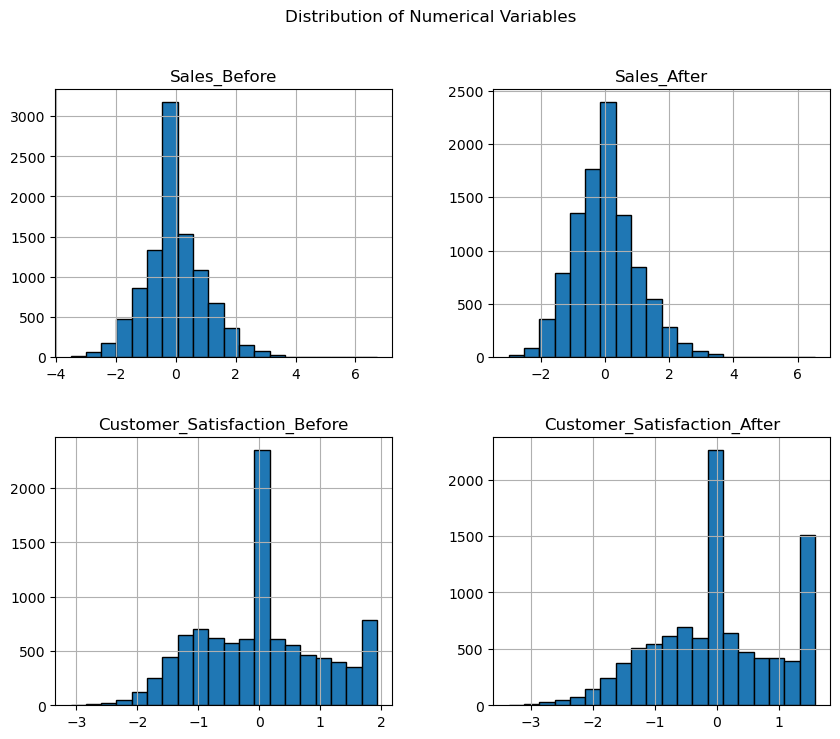

In [395]:
df[['Sales_Before', 'Sales_After','Customer_Satisfaction_Before','Customer_Satisfaction_After']].hist(figsize=(10, 8), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Variables')
plt.show()

In [396]:
from sklearn.model_selection import train_test_split

In [397]:
x=df.drop(columns='Customer_Satisfaction_After',axis=1)
y=df['Customer_Satisfaction_After']

In [398]:
x

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Purchase_Made
0,0,0,0.724915,0.244289,0.294597,0
1,1,0,0.848980,1.232171,1.930144,1
2,0,0,-0.917246,-1.221527,1.851371,0
3,0,2,-0.226573,-0.614834,-1.343262,1
4,0,0,0.511461,-0.082192,0.894803,1
...,...,...,...,...,...,...
9995,1,1,1.101166,1.643262,1.183205,1
9996,0,0,-0.337369,-0.773378,1.430183,1
9997,1,1,0.087443,0.522273,-0.918010,0
9998,1,2,-0.006554,1.847242,-0.261175,0


In [399]:
from sklearn.linear_model import LinearRegression
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [400]:
from sklearn.metrics import mean_squared_error
from sklearn import metrics
y_pred=model.predict(x_test)
training_data_prediction=model.predict(x_train)

In [401]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):",mse)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)
r2_test=metrics.r2_score(y_test,y_pred)
r2_train=metrics.r2_score(y_train,training_data_prediction)
print("R squred for the training data = ",r2_train*100)
print("R squared for the testing data = ",r2_test*100)

Mean Squared Error (MSE): 0.5482041493633688
Mean Absolute Error (MAE): 0.5764446522903971
R squred for the training data =  48.96826389187784
R squared for the testing data =  46.01748231395013


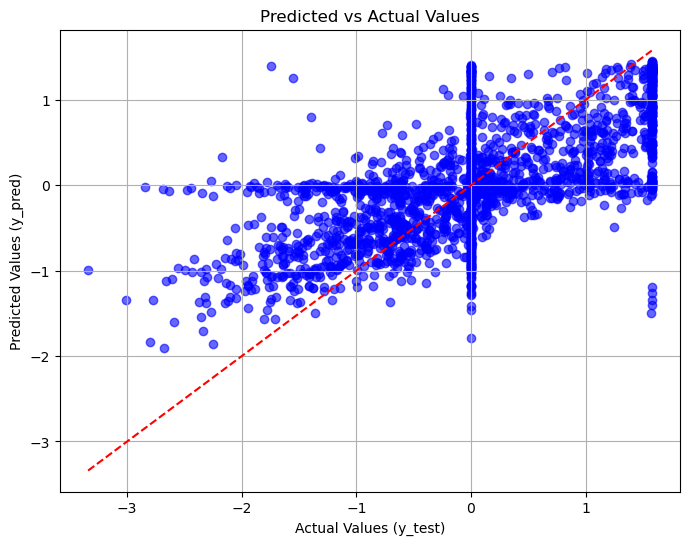

In [402]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.grid(True)
plt.show()


In [403]:
# KNN Regressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [404]:
nX_train, nX_test, ny_train, ny_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
nX_train = scaler.fit_transform(nX_train)
nX_test = scaler.transform(nX_test)
knn_reg = KNeighborsRegressor(n_neighbors=6)
knn_reg.fit(nX_train, ny_train)
ny_pred = knn_reg.predict(nX_test)

In [405]:
nmse = mean_squared_error(ny_test, ny_pred)
nr2 = r2_score(ny_test, ny_pred)
nmae = mean_absolute_error(ny_test, ny_pred)
print("Mean Absolute Error:", nmae)
print("Mean Squared Error:", nmse)
print("R² Score:", nr2*100)

Mean Absolute Error: 0.6102008236741224
Mean Squared Error: 0.587291517202736
R² Score: 42.446143342162436


In [406]:
if nmae < mae and nmse < mse and nr2 < r2:
    print("The KNN model performs better than the linear model.")
else:
    print("The linear model performs better than the KNN model.")

The linear model performs better than the KNN model.


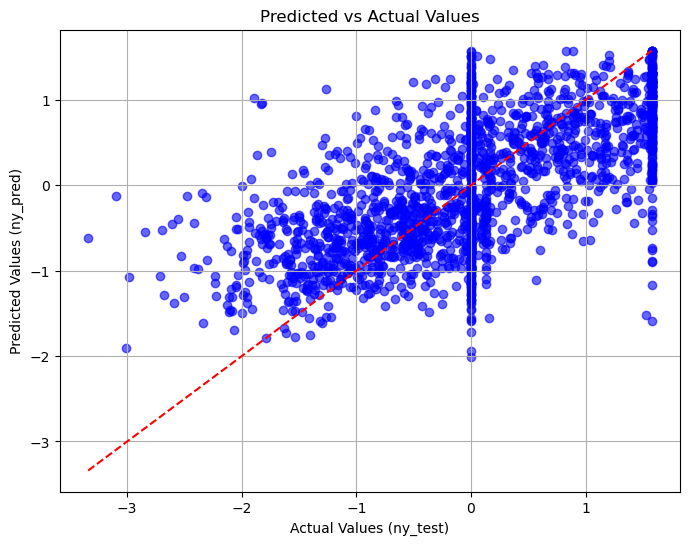

In [407]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(ny_test, ny_pred, color='blue', alpha=0.6)
plt.plot([min(ny_test), max(ny_test)], [min(ny_test), max(ny_test)], color='red', linestyle='--')
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual Values (ny_test)')
plt.ylabel('Predicted Values (ny_pred)')
plt.grid(True)
plt.show()


In [408]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN'],
    'R²': [r2_train, nr2],
    'MSE': [mse, nmse],
    'MAE': [mae, nmae]
})
model_comparison


,Model,R²,MSE,MAE
0,Linear Regression,0.489683,0.548204,0.576445
1,KNN,0.424461,0.587292,0.610201
